![logo_ironhack_blue 7](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)



---


# **Lab-14: Regression Analysis.**


---



### Alumno: *Juan Alberto Peñalver Alvarez*


---



### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file)

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table.
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
# Create the dataframe from the table
student_data = pd.DataFrame({
    'Age': [17, 51, 27, 21, 36, 48, 19, 26, 54, 30],
    'Tardies': [10, 1, 5, 9, 4, 2, 9, 6, 0, 3]
})

student_data


,Age,Tardies
0,17,10
1,51,1
2,27,5
3,21,9
4,36,4
5,48,2
6,19,9
7,26,6
8,54,0
9,30,3


Draw a dispersion diagram (scatter plot) for the data.

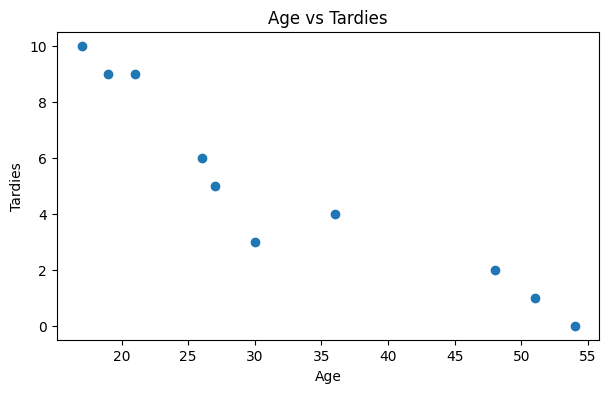

In [3]:
# Scatter plot: Age vs Tardies
plt.figure(figsize=(7,4))
plt.scatter(student_data['Age'], student_data['Tardies'])
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Age vs Tardies')
plt.show()


Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

I see a **negative** relationship: as **Age increases, Tardies tends to decrease**.
A reasonable hypothesis is that **younger students are late more often**, while older students are late less often.


Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [4]:
# Covariance measures *joint variability* in the original units (Age-years * Tardies-counts).
# Correlation is a *standardized* covariance in [-1, 1], unitless, and therefore comparable across datasets.

cov_age_tardies = student_data['Age'].cov(student_data['Tardies'])
corr_age_tardies = student_data['Age'].corr(student_data['Tardies'])

cov_age_tardies, corr_age_tardies


(np.float64(-45.56666666666666), np.float64(-0.9391626886887122))

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [5]:
# Outcome (dependent) variable: Tardies
# Predictor (independent) variable: Age
# This is a simple **linear regression**: Tardies = β0 + β1 * Age + ε

model_students = smf.ols('Tardies ~ Age', data=student_data).fit()
model_students.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Tardies   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     59.81
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           5.57e-05
Time:                        17:14:59   Log-Likelihood:                -15.622
No. Observations:                  10   AIC:                             35.24
Df Residuals:                       8   BIC:                             35.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.8888      1.111     11.605      0.000      10.328      15.450
Age           -0.2428      0.031     -7.734      0.000      -0.315      -0.170
==============================================================================
Omnibus:                        3.949   Durbin-Watson:                   1.754
Prob(Omnibus):                  0.139   Jarque-Bera (JB):                1.714
Skew:                          -1.014   Prob(JB):                        0.424
Kurtosis:                       3.069   Cond. No.                         96.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Plot your regression model on your scatter plot.

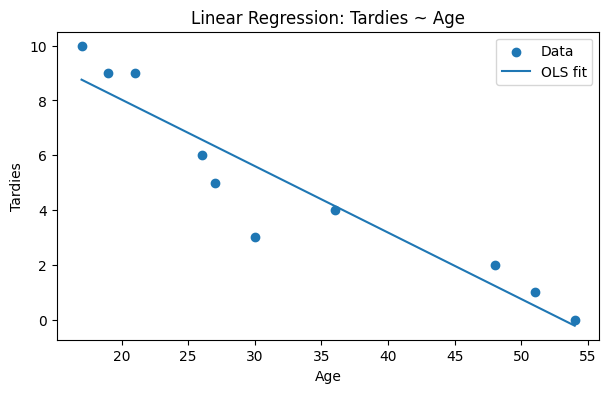

In [6]:
# Plot scatter + regression line
plt.figure(figsize=(7,4))
plt.scatter(student_data['Age'], student_data['Tardies'], label='Data')

x = np.linspace(student_data['Age'].min(), student_data['Age'].max(), 100)
y_hat = model_students.params['Intercept'] + model_students.params['Age'] * x
plt.plot(x, y_hat, label='OLS fit')

plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Linear Regression: Tardies ~ Age')
plt.legend()
plt.show()


Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

From the fitted line, the **slope for Age is negative**, so each additional year of age is associated with **fewer** tardies on average.

Because this is a **small sample (n=10)** and we only have one predictor, conclusions should be cautious.
Still, if the p-value for Age is low and R² is reasonably high, we can say **Age is a meaningful predictor** of tardiness in this dataset.


## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables.

In [7]:
!pwd


/content


In [8]:
import os
print(os.getcwd())


/content


In [9]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
# Import any libraries you may need & the data
from pathlib import Path

# Cambia a la carpeta que quieras
#%cd /content/drive/MyDrive/nombre_de_tu_carpeta
%cd /content/drive/MyDrive/IronHack/csv/

# Cambia a la carpeta que quieras
#%cd /content/drive/MyDrive/IronHack/Data_Machine_Learning/Lab&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/your-code/
#vehicles_path ="/content/drive/MyDrive/IronHack/csv/" #"/Data_Machine_Learning/Labs&Projects/Lab-14/lab-regression-analysis-en-main_solved/lab-regression-en-main/vehicles.csv"

# The notebook lives in ./your-code; data files are usually one level up
candidates = [Path("vehicles.csv"), Path("../vehicles.csv"), Path("../../vehicles.csv")]
vehicles_path = next((p for p in candidates if p.exists()), None)
print(vehicles_path)

if vehicles_path is None:
    raise FileNotFoundError("Could not find vehicles.csv in expected locations.")

vehicles = pd.read_csv(vehicles_path, sep=',')
vehicles.head()


/content/drive/MyDrive/IronHack/csv
vehicles.csv


,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable.

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [11]:
# Correlations with the outcome: 'CO2 Emission Grams/Mile'
outcome = 'CO2 Emission Grams/Mile'
predictors = ['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year']

# Ensure numeric
df = vehicles[[outcome] + predictors].apply(pd.to_numeric, errors='coerce').dropna()

corrs = df.corr(numeric_only=True)[outcome].drop(outcome).sort_values(key=lambda s: s.abs(), ascending=False)
corrs

# Typically, we expect:
# - Combined MPG to be strongly (negatively) correlated with CO2 (higher MPG => lower CO2),
# - Fuel Barrels/Year and Fuel Cost/Year to be strongly (positively) correlated with CO2.
# The weakest predictor will be the one with the smallest |correlation| above.


,CO2 Emission Grams/Mile
Fuel Barrels/Year,0.986189
Fuel Cost/Year,0.930865
Combined MPG,-0.926229
Cylinders,0.752393
Year,-0.222300


Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [12]:
# Multiple linear regression (OLS) with several predictors
formula = f'Q("{outcome}") ~ Year + Cylinders + Q("Fuel Barrels/Year") + Q("Combined MPG") + Q("Fuel Cost/Year")'
model_vehicles = smf.ols(formula, data=df).fit()
model_vehicles


Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [13]:
# Regression summary
summary = model_vehicles.summary()
summary

# Interpretation (high level):
# - Look at p-values to see which predictors are statistically significant.
# - Compare standardized effect indirectly via scale/units; for direct comparison, standardize features first.
# - Typically, 'Combined MPG' and 'Fuel Barrels/Year' carry strong signal for CO2 because they directly encode fuel efficiency/consumption.


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     Q("CO2 Emission Grams/Mile")   R-squared:                       0.981
Model:                                      OLS   Adj. R-squared:                  0.981
Method:                           Least Squares   F-statistic:                 3.687e+05
Date:                          Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                                  17:15:45   Log-Likelihood:            -1.5173e+05
No. Observations:                         35952   AIC:                         3.035e+05
Df Residuals:                             35946   BIC:                         3.035e+05
Df Model:                                     5                                         
Covariance Type:                      nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                769.8883     19.392     39.702      0.000     731.880     807.897
Year                      -0.3206      0.010    -33.060      0.000      -0.340      -0.302
Cylinders                  1.8788      0.083     22.598      0.000       1.716       2.042
Q("Fuel Barrels/Year")    19.0529      0.061    311.600      0.000      18.933      19.173
Q("Combined MPG")         -3.0404      0.042    -71.645      0.000      -3.124      -2.957
Q("Fuel Cost/Year")        0.0323      0.000     67.025      0.000       0.031       0.033
==============================================================================
Omnibus:                    71055.645   Durbin-Watson:                   0.747
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        246941260.782
Skew:                          15.902   Prob(JB):                         0.00
Kurtosis:                     407.766   Cond. No.                     6.20e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.2e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended.

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression.
First, build a dataframe with the data.

In [14]:
# Build dataframe for party data
party = pd.DataFrame({
    'Invited': [1, 3, 4, 6, 8, 9, 11, 14],
    'Attended': [1, 2, 4, 4, 5, 7, 8, 13]
})
party


,Invited,Attended
0,1,1
1,3,2
2,4,4
3,6,4
4,8,5
5,9,7
6,11,8
7,14,13


Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

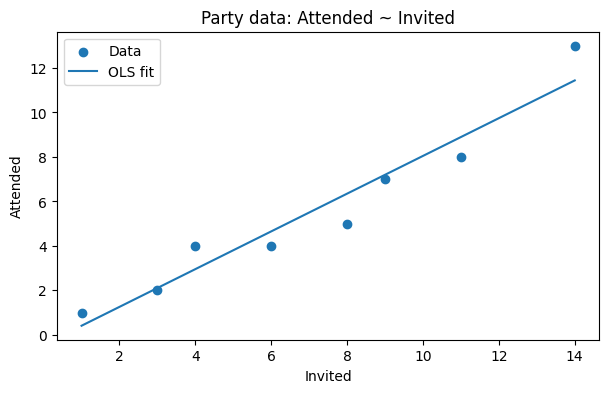

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Attended   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     81.81
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           0.000102
Time:                        17:15:54   Log-Likelihood:                -10.800
No. Observations:                   8   AIC:                             25.60
Df Residuals:                       6   BIC:                             25.76
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4394      0.759     -0.579      0.584      -2.297       1.418
Invited        0.8485      0.094      9.045      0.000       0.619       1.078
==============================================================================
Omnibus:                        0.556   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.757   Jarque-Bera (JB):                0.514
Skew:                           0.261   Prob(JB):                        0.773
Kurtosis:                       1.873   Cond. No.                         16.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# Scatter plot and regression line
party_model = smf.ols('Attended ~ Invited', data=party).fit()

plt.figure(figsize=(7,4))
plt.scatter(party['Invited'], party['Attended'], label='Data')

x = np.linspace(party['Invited'].min(), party['Invited'].max(), 100)
y = party_model.params['Intercept'] + party_model.params['Invited'] * x
plt.plot(x, y, label='OLS fit')

plt.xlabel('Invited')
plt.ylabel('Attended')
plt.title('Party data: Attended ~ Invited')
plt.legend()
plt.show()

party_model.summary()


What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

The scatter plot looks **approximately linear and increasing**: inviting more people generally leads to more attendees.
The regression output quantifies that relationship (slope > 0). Any point far from the overall pattern may have high influence on the fitted line.


Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model.

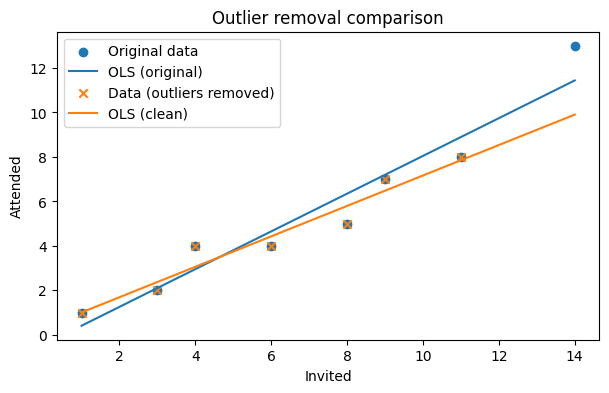

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:               Attended   R-squared:                       0.932
 Model:                            OLS   Adj. R-squared:                  0.920
 Method:                 Least Squares   F-statistic:                     81.81
 Date:                Sun, 01 Mar 2026   Prob (F-statistic):           0.000102
 Time:                        17:15:59   Log-Likelihood:                -10.800
 No. Observations:                   8   AIC:                             25.60
 Df Residuals:                       6   BIC:                             25.76
 Df Model:                           1                                         
 Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
 ---------------------------------------------------------------------

In [16]:
# Identify potential outliers via standardized residuals, remove them, and refit
influence = party_model.get_influence()
std_resid = influence.resid_studentized_internal

party_with_resid = party.copy()
party_with_resid['std_resid'] = std_resid

# Common rule of thumb: |studentized residual| > 2 suggests a potential outlier
outlier_mask = party_with_resid['std_resid'].abs() > 2
party_with_resid.sort_values('std_resid', key=lambda s: s.abs(), ascending=False)

# Remove flagged outliers (if any)
party_clean = party.loc[~outlier_mask].copy()

party_model_clean = smf.ols('Attended ~ Invited', data=party_clean).fit()

# Plot original + clean fit for comparison
plt.figure(figsize=(7,4))
plt.scatter(party['Invited'], party['Attended'], label='Original data')

x = np.linspace(party['Invited'].min(), party['Invited'].max(), 100)
y_orig = party_model.params['Intercept'] + party_model.params['Invited'] * x
plt.plot(x, y_orig, label='OLS (original)')

plt.scatter(party_clean['Invited'], party_clean['Attended'], label='Data (outliers removed)', marker='x')

y_clean = party_model_clean.params['Intercept'] + party_model_clean.params['Invited'] * x
plt.plot(x, y_clean, label='OLS (clean)')

plt.xlabel('Invited')
plt.ylabel('Attended')
plt.title('Outlier removal comparison')
plt.legend()
plt.show()

party_model.summary(), party_model_clean.summary()


What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

After removing the influential/outlier point, the fitted regression line typically changes (often noticeably in small datasets).
This indicates that the removed point had **high leverage/influence**. Without it, the remaining data may follow a clearer linear pattern
(and the model fit statistics like R² and the slope estimate may change).
